## 15 - Capstone Project: Student Data Dashboard

## Objective
Build a **complete 9-chart visual dashboard** for the student dataset using **pure `plt.` pyplot style** - applying everything learned in this course.

## Dashboard layout - 3 rows × 3 columns
```
┌─────────────────┬─────────────────┬─────────────────┐
│  1. Histogram   │  2. Bar Chart   │  3. Scatter     │
│  Score dist.    │  Subject avgs   │  Study vs Score │
├─────────────────┼─────────────────┼─────────────────┤
│  4. Pie/Donut   │  5. Grouped Bar │  6. Heatmap     │
│  Grade split    │  City-subject   │  Correlation    │
├─────────────────┼─────────────────┼─────────────────┤
│  7. Horiz. Bar  │  8. Box Plot    │  9. Line Chart  │
│  Top 10 students│  Subject spread │  Attend vs Score│
└─────────────────┴─────────────────┴─────────────────┘
```

## What each chart reveals
| Chart | Insight |
|-------|---------|
| 1. Histogram | Is the overall score distribution normal or skewed? |
| 2. Bar | Which subject has the highest/lowest average? |
| 3. Scatter | Does more study lead to higher scores? |
| 4. Donut | What fraction of students got each grade? |
| 5. Grouped bar | Which city performs best in which subject? |
| 6. Heatmap | Are all subjects correlated with each other? |
| 7. Horizontal bar | Who are the top 10 performers? |
| 8. Box plot | Which subject has the most consistent scores? |
| 9. Line | Does higher attendance improve scores? |


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Creating Dataset

In [2]:
rng = np.random.default_rng(42)
n   = 50

study   = rng.uniform(3, 15, n)
maths   = (study * 4   + rng.normal(25, 8, n)).clip(0, 100).round(1)
science = (study * 3.5 + rng.normal(28, 9, n)).clip(0, 100).round(1)
english = (study * 3   + rng.normal(36, 8, n)).clip(0, 100).round(1)
compsci = (study * 3.8 + rng.normal(28, 8, n)).clip(0, 100).round(1)
attend  = (study * 2.5 + rng.normal(55, 8, n)).clip(40, 100).round(1)

df = pd.DataFrame({
    'name':        [f'S{i:03d}' for i in range(1, n + 1)],
    'gender':      rng.choice(['Female', 'Male'], n),
    'city':        rng.choice(['Delhi', 'Mumbai', 'Pune', 'Bangalore', 'Hyderabad'], n),
    'study_hours': study.round(1),
    'maths':       maths,
    'science':     science,
    'english':     english,
    'compSci':     compsci,
    'attendance':  attend,
})
df['average'] = df[['maths','science','english','compSci']].mean(axis=1).round(2)

conds = [df['average']>=85, df['average']>=70, df['average']>=55, df['average']>=40]
df['grade'] = np.select(conds, ['A','B','C','D'], default='F')

SCORE_COLS = ['maths', 'science', 'english', 'compSci']
COLORS     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
SUB_LABELS = ['Maths', 'Science', 'English', 'CompSci']

print(f'Dataset ready: {df.shape}')
print(f'Grade distribution:\n{df["grade"].value_counts().sort_index()}')

Dataset ready: (50, 11)
Grade distribution:
grade
A     1
B    16
C    16
D    15
F     2
Name: count, dtype: int64


In [3]:
def clean_ax():
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

### BUILD THE DASHBOARD

C:\Users\Purvi jain\AppData\Local\Temp\ipykernel_5704\1730775399.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([df[c] for c in SCORE_COLS], labels=SUB_LABELS,


Dashboard saved: student_dashboard_pyplot.png


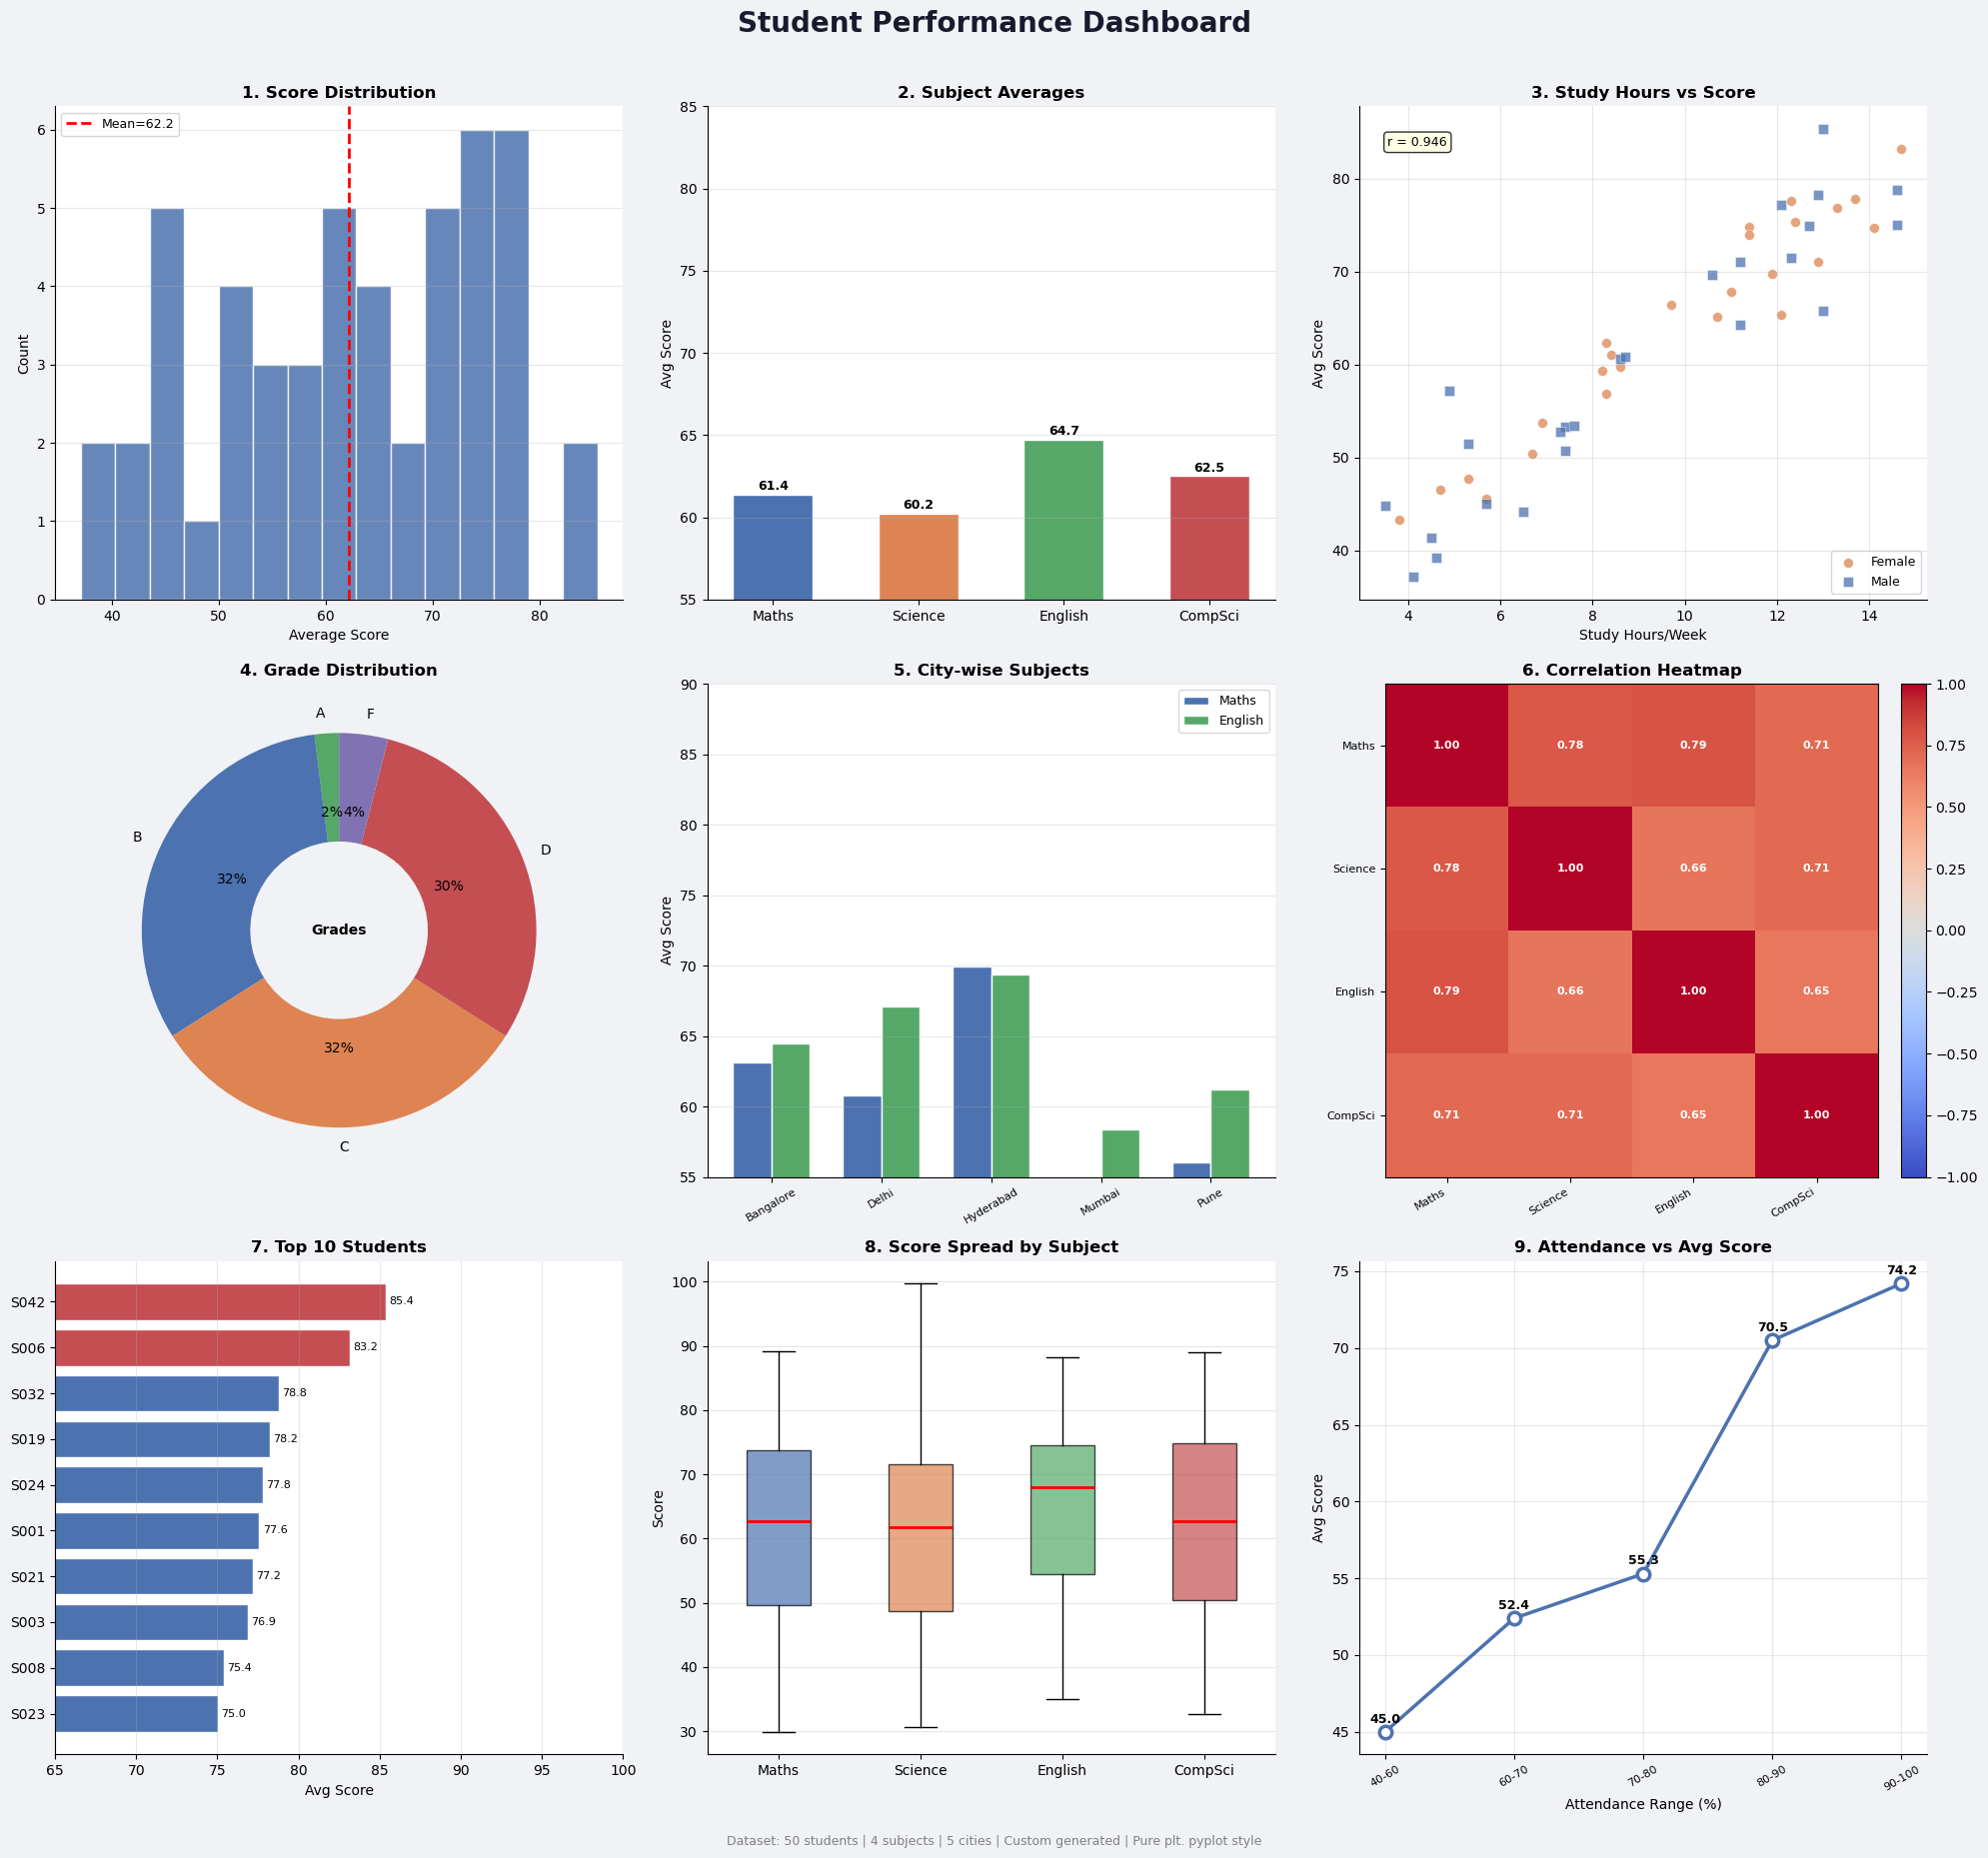

In [4]:
plt.figure(figsize=(20, 18), facecolor='#F0F2F5')
plt.suptitle('Student Performance Dashboard',
             fontsize=20, fontweight='bold', y=1.01, color='#1a1a2e')

# Chart 1 : Score Distribution
plt.subplot(3, 3, 1)
plt.hist(df['average'], bins=15, color='#4C72B0', edgecolor='white', alpha=0.85)
plt.axvline(df['average'].mean(), color='red', lw=2, ls='--',
            label=f"Mean={df['average'].mean():.1f}")
plt.title('1. Score Distribution', fontweight='bold')
plt.xlabel('Average Score')
plt.ylabel('Count')
plt.legend(fontsize=9)
plt.grid(axis='y', alpha=0.3)
clean_ax()

# Chart 2 : Subject Averages
plt.subplot(3, 3, 2)
sub_avg = df[SCORE_COLS].mean().round(1)
bars = plt.bar(SUB_LABELS, sub_avg.values, color=COLORS, edgecolor='white', width=0.55)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')
plt.title('2. Subject Averages', fontweight='bold')
plt.ylabel('Avg Score')
plt.ylim(55, 85)
plt.grid(axis='y', alpha=0.3)
clean_ax()

# Chart 3 : Study Hours vs Score
plt.subplot(3, 3, 3)
for g, col, mk in [('Female','#DD8452','o'),('Male','#4C72B0','s')]:
    mask = df['gender'] == g
    plt.scatter(df[mask]['study_hours'], df[mask]['average'],
                color=col, marker=mk, s=50, alpha=0.75,
                edgecolors='white', linewidths=0.4, label=g)
r = df['study_hours'].corr(df['average'])
plt.text(0.05, 0.92, f'r = {r:.3f}', transform=plt.gca().transAxes,
         fontsize=9, bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8))
plt.title('3. Study Hours vs Score', fontweight='bold')
plt.xlabel('Study Hours/Week')
plt.ylabel('Avg Score')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
clean_ax()

# Chart 4 : Grade Donut 
plt.subplot(3, 3, 4)
grade_ct = df['grade'].value_counts().sort_index()
plt.pie(grade_ct.values, labels=grade_ct.index, autopct='%1.0f%%',
        colors=['#55A868','#4C72B0','#DD8452','#C44E52','#8172B3'],
        startangle=90, wedgeprops=dict(width=0.55))
plt.text(0, 0, 'Grades', ha='center', va='center', fontsize=10, fontweight='bold')
plt.title('4. Grade Distribution', fontweight='bold')

# Chart 5 : City Subject Grouped Bar
plt.subplot(3, 3, 5)
city_stats = df.groupby('city')[['maths','english']].mean().round(1)
x = np.arange(len(city_stats))
w = 0.35
plt.bar(x-w/2, city_stats['maths'],   w, label='Maths',   color='#4C72B0', edgecolor='white')
plt.bar(x+w/2, city_stats['english'], w, label='English', color='#55A868', edgecolor='white')
plt.xticks(x, city_stats.index, rotation=30, fontsize=8)
plt.title('5. City-wise Subjects', fontweight='bold')
plt.ylabel('Avg Score')
plt.ylim(55, 90)
plt.legend(fontsize=9)
plt.grid(axis='y', alpha=0.3)
clean_ax()

# Chart 6 : Correlation Heatmap
plt.subplot(3, 3, 6)
corr = df[SCORE_COLS].corr().round(2)
im   = plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(4), SUB_LABELS, rotation=30, ha='right', fontsize=8)
plt.yticks(range(4), SUB_LABELS, fontsize=8)
for i in range(4):
    for j in range(4):
        val = corr.values[i,j]
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                 color='white' if abs(val)>0.5 else 'black', fontweight='bold')
plt.title('6. Correlation Heatmap', fontweight='bold')

# Chart 7 : Top 10 Students 
plt.subplot(3, 3, 7)
top10 = df.nlargest(10, 'average')[['name','average']].sort_values('average')
bar_c = ['#C44E52' if v >= 80 else '#4C72B0' for v in top10['average']]
plt.barh(top10['name'], top10['average'], color=bar_c, edgecolor='white')
for i, (_, row) in enumerate(top10.iterrows()):
    plt.text(row['average']+0.2, i, f"{row['average']:.1f}", va='center', fontsize=8)
plt.title('7. Top 10 Students', fontweight='bold')
plt.xlabel('Avg Score')
plt.xlim(65, 100)
plt.grid(axis='x', alpha=0.3)
clean_ax()

# Chart 8 : Box Plot
plt.subplot(3, 3, 8)
bp = plt.boxplot([df[c] for c in SCORE_COLS], labels=SUB_LABELS,
                 patch_artist=True, medianprops=dict(color='red', lw=2))
for patch, col in zip(bp['boxes'], COLORS):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
plt.title('8. Score Spread by Subject', fontweight='bold')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)
clean_ax()

# Chart 9 : Attendance vs Score
plt.subplot(3, 3, 9)
attend_bins = pd.cut(df['attendance'], bins=[40,60,70,80,90,100],
                     labels=['40-60','60-70','70-80','80-90','90-100'])
trend = df.groupby(attend_bins, observed=True)['average'].mean().round(1)
plt.plot(range(len(trend)), trend.values, color='#4C72B0', lw=2.5,
         marker='o', ms=9, markerfacecolor='white', markeredgewidth=2.5)
for i, val in enumerate(trend.values):
    plt.text(i, val + 0.4, f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.xticks(range(len(trend)), trend.index, rotation=30, fontsize=8)
plt.title('9. Attendance vs Avg Score', fontweight='bold')
plt.xlabel('Attendance Range (%)')
plt.ylabel('Avg Score')
plt.grid(True, alpha=0.3)
clean_ax()

# Footer
plt.figtext(0.5, -0.01,
    f'Dataset: {n} students | 4 subjects | 5 cities | Custom generated | Pure plt. pyplot style',
    ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('student_dashboard_pyplot.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F2F5')
print('Dashboard saved: student_dashboard_pyplot.png')
plt.show()